In [1]:
import litminion as lm

In [3]:
lm.set_email("rebecca.sessa@studio.unibo.it")

In [4]:
#download

df = lm.download_pubmed(
    query="JAK inhibitor",
    max_results=10,
)

df.head()

,PMID,Title,Abstract,Journal,Year,Authors,PublicationType
0,42364375,Efficacy and safety of JAK inhibitors in Behçe...,Given the active role of the JAK signaling pat...,Seminars in arthritis and rheumatism,2026,Bercemhan Sulu; Sinem Nihal Esatoglu; Gozde Ku...,Journal Article
1,42364256,Ocular sarcoidosis: from clinical signs to tar...,Ocular sarcoidosis is a frequent manifestation...,Current opinion in immunology,2026,Thomas El Jammal; Robin Jacquot; Stéphane Abra...,Journal Article; Review
2,42364020,Filgotinib induces apoptosis in colorectal can...,Colorectal cancer remains a significant health...,Molecular biology reports,2026,Ying Zhou; Zhen Li; Yanyang Zhao; Chenmeng Li;...,Journal Article
3,42362915,Clinical and prognostic significance of concom...,There is growing interest in the association b...,Annals of hematology,2026,Alessandro Costa; Olga Mulas; Marianna Greco; ...,Journal Article
4,42362624,Differential functional and lipidomic impact o...,High-density lipoprotein (HDL) presents athero...,Scientific reports,2026,Eftaxia-Konstantina Valanti; Anastasia-Georgia...,Journal Article


In [5]:
#preprocess
preprocessor = lm.ClassicalPreprocessor()

processed = preprocessor.transform_corpus(
    df["Abstract"]
)

print(processed[0])

give active role JAK signal pathway multifactorial immune mediator observe Behçet syndrome BS JAK inhibitor JAKi promise agent systematic literature review SLR aim evaluate efficacy safety JAKi BS systematic literature search conduct Embase PubMed Cochrane Library identify report efficacy safety JAKi patient BS SLR protocol register International Prospective Registry Systematic Reviews CRD420251000172 additionally present patient gastrointestinal involvement treat upadacitinib patient man mean SD age year tofacitinib baricitinib upadacitinib patient previous conventional immunosuppressive refractory prior tumor necrosis factor inhibitor JAKi combination conventional immunosuppressive and/or glucocorticoid patient primary indication JAKi initiation gastrointestinal involvement patient include patient vascular involvement uveitis mucocutaneous and/or articular involvement patient remission rate overall gastrointestinal vascular eye involvement adverse event observe patient thrombotic eve

In [6]:
#extractor

extractor = lm.NGramExtractor(
    ngram_range=(2, 2),
)

In [7]:
#fit

matrix = extractor.fit_transform(processed)

matrix.shape

(9, 1314)

In [8]:
#feat names

features = extractor.get_feature_names()

print(type(features))
print(len(features))
print(features[:20])

<class 'numpy.ndarray'>
1314
['23p19 agent' '23p19 jaki' '50 75' '50 response' '50 sub' '75 90'
 '75 primary' '75 response' '90 response' 'a1 saa1' 'abatacept jak'
 'abatacept significant' 'abatacept study' 'abrocitinib appear'
 'abrocitinib associate' 'abrocitinib group' 'abrocitinib mg'
 'abrocitinib remain' 'absence broad' 'academy dermatology']


In [10]:
#ngram counts

counts = extractor.get_ngram_counts()

print(type(counts))

len(counts)

<class 'dict'>


1314

In [11]:
list(counts.items())[:20]

[('23p19 agent', 1),
 ('23p19 jaki', 1),
 ('50 75', 1),
 ('50 response', 2),
 ('50 sub', 1),
 ('75 90', 1),
 ('75 primary', 1),
 ('75 response', 1),
 ('90 response', 1),
 ('a1 saa1', 1),
 ('abatacept jak', 1),
 ('abatacept significant', 1),
 ('abatacept study', 1),
 ('abrocitinib appear', 1),
 ('abrocitinib associate', 1),
 ('abrocitinib group', 1),
 ('abrocitinib mg', 3),
 ('abrocitinib remain', 1),
 ('absence broad', 1),
 ('academy dermatology', 1)]

In [12]:
#top n grams

extractor.get_top_ngrams(
    n=20,
)

[('moderate severe', 6),
 ('jak inhibitor', 5),
 ('janus kinase', 5),
 ('safety profile', 5),
 ('adverse event', 4),
 ('disease activity', 4),
 ('improvement hdl', 4),
 ('kinase inhibitor', 4),
 ('real world', 4),
 ('systemic aid', 4),
 ('abrocitinib mg', 3),
 ('bdmard tsdmards', 3),
 ('bibliometric analysis', 3),
 ('clinical trial', 3),
 ('easi 50', 3),
 ('hair loss', 3),
 ('hdl atheroprotective', 3),
 ('inhibitor jaki', 3),
 ('patient moderate', 3),
 ('pibd patient', 3)]

In [13]:
#df
df_ngrams = extractor.to_dataframe(
    n=20,
)

df_ngrams

,N-gram,Count
0,moderate severe,6
1,jak inhibitor,5
2,janus kinase,5
3,safety profile,5
4,adverse event,4
5,disease activity,4
6,improvement hdl,4
7,kinase inhibitor,4
8,real world,4
9,systemic aid,4


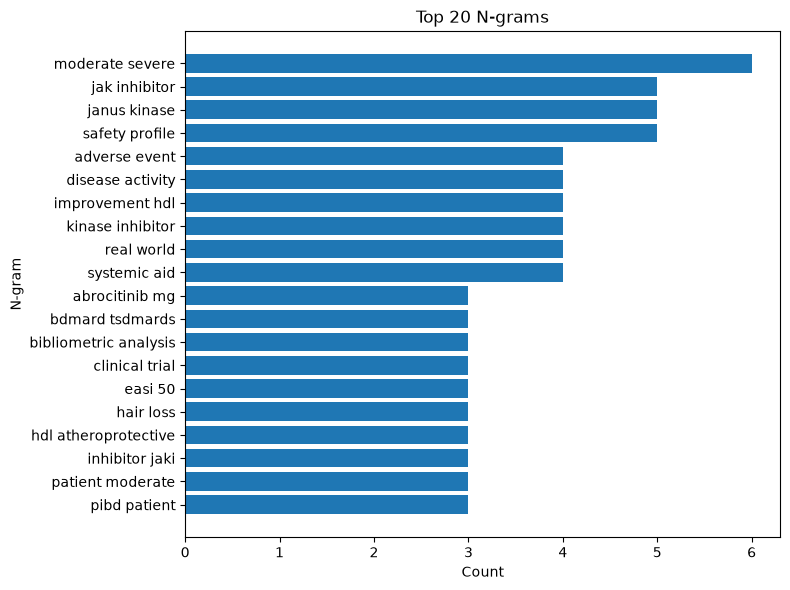

matplotlib.axes._axes.Axes

In [14]:
ax = extractor.plot(
    n=20,
)

type(ax)

In [15]:
tri = lm.NGramExtractor(
    ngram_range=(3, 3),
)

tri.fit(processed)

tri.get_top_ngrams(20)

[('janus kinase inhibitor', 4),
 ('moderate severe ad', 3),
 ('patient moderate severe', 3),
 ('adult patient moderate', 2),
 ('anti il 23p19', 2),
 ('anti tumor effect', 2),
 ('cck crystal violet', 2),
 ('cell viability proliferation', 2),
 ('crystal violet edu', 2),
 ('drug approval trial', 2),
 ('easi 50 response', 2),
 ('efficacy safety jaki', 2),
 ('favorable safety profile', 2),
 ('hair loss treatment', 2),
 ('hdl saa1 level', 2),
 ('large prospective study', 2),
 ('long term safety', 2),
 ('meta level comparison', 2),
 ('mg abrocitinib mg', 2),
 ('novel anti il', 2)]

In [16]:
import litminion as lm

extractor = lm.NGramExtractor()

try:
    extractor.get_ngram_counts()

except Exception as e:
    print(type(e).__name__)
    print(e)

NotFittedError
This CountVectorizer instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


In [17]:
extractor = lm.NGramExtractor()

try:
    extractor.transform(["hello world"])

except Exception as e:
    print(type(e).__name__)
    print(e)

ValueError
The n-gram extractor has not been fitted. Call 'fit()' or 'fit_transform()' first.


In [18]:
extractor.fit(processed)

try:
    extractor.get_top_ngrams(0)

except Exception as e:
    print(type(e).__name__)
    print(e)

ValueError
'n' must be greater than zero.
